In [8]:
from ssh_chain_single import PHOTONICChain as Model1
from ssh_chain        import PHOTONICChain as Model2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from joblib import Parallel, delayed
from concurrent.futures import ProcessPoolExecutor
import functools
import scipy.sparse.linalg as sla
import scipy.sparse as sp
import graphics_template

In [ ]:
# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N               = 6
fock_photon     = 8
Omega_J         = 1.0
Chi_J           = 0.0
base_excitations = 1
k_states        = 4 * N - 1
Omega_C         = 0.2
Chi_C_values    = np.linspace(-0.75, 0.75, 20)
gamma_values    = [0.01, 0.03, 0.05, 0.1]

In [4]:


# ------------------------------------------------------------------ #
# IPR: works for both model1 (flat) and model2 (dict) indexing
# ------------------------------------------------------------------ #
def compute_ipr_batch(vecs, chain, model_type):
    """
    model_type: 'flat'  -> model1 (fock_states is a 2D array, fock_state_index is flat dict)
                'dict'  -> model2 (fock_states is dict of sectors, fock_offsets exists)
    """
    d_ph     = chain.fock_photon
    d_mat    = chain.fock_dim
    k        = vecs.shape[1]

    chain.build_squeezed_vacuum(truncation=1)

    # --- build _new_to_old_cache ---
    chain._new_to_old_cache = {}
    for col in range(k):
        decomp = chain.decompose_tensor_state(vecs[:, col])
        for alpha, matter_dict in decomp.items():
            for new_state_tuple in matter_dict:
                if new_state_tuple not in chain._new_to_old_cache:
                    chain._new_to_old_cache[new_state_tuple] = chain.new_to_old_fock(
                        np.array(new_state_tuple, dtype=int)
                    )

    all_old_states = set()
    for old_dict in chain._new_to_old_cache.values():
        all_old_states.update(old_dict.keys())

    sorted_states     = sorted(all_old_states, key=lambda s: (sum(s), s))
    state_to_idx      = {s: i for i, s in enumerate(sorted_states)}
    d_mat_old         = len(sorted_states)
    sorted_states_arr = np.array(sorted_states, dtype=float)   # (d_mat_old, 2N)

    # --- change-of-basis matrix C: (d_mat_old, d_mat) ---
    C = np.zeros((d_mat_old, d_mat), dtype=complex)

    for new_state_tuple, old_dict in chain._new_to_old_cache.items():
        exc = sum(new_state_tuple)

        if model_type == 'flat':
            if new_state_tuple not in chain.fock_state_index:
                continue
            col_c = chain.fock_state_index[new_state_tuple]
        else:
            if exc not in chain.fock_state_index:
                continue
            if new_state_tuple not in chain.fock_state_index[exc]:
                continue
            col_c = chain.fock_offsets[exc] + chain.fock_state_index[exc][new_state_tuple]

        norm = np.sqrt(sum(abs(v)**2 for v in old_dict.values()))
        for old_state, coeff in old_dict.items():
            C[state_to_idx[old_state], col_c] += coeff / (norm if norm > 1e-15 else 1.0)

    vecs_3d  = vecs.reshape(d_ph, d_mat, k)
    amp_3d   = np.tensordot(C, vecs_3d, axes=([1], [1])).transpose(1, 0, 2)
    diag_rho = np.sum(np.abs(amp_3d)**2, axis=0)              # (d_mat_old, k)
    all_dist = sorted_states_arr.T @ diag_rho                 # (2N, k)
    totals   = all_dist.sum(axis=0)
    return np.where(totals < 1e-15, 0.0, np.sum(all_dist**2, axis=0) / totals**2)

# ------------------------------------------------------------------ #
# Compute spectra + IPR for one Chi_C
# ------------------------------------------------------------------ #
def make_edge_lifting_perturbation(chain, strength=1e-6):
    """
    Diagonal perturbation: delta_i = strength * (exp(-i/xi) - exp(-(2N-1-i)/xi))
    Positive on left edge sites, negative on right edge sites.
    This lifts the degeneracy without mixing the states significantly.
    """
    n     = 2 * chain.N
    xi    = n / 4.0   # decay length ~ quarter chain
    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # weight per site: +exp on left, -exp on right
    site_weights = np.array([np.exp(-i / xi) - np.exp(-(n - 1 - i) / xi)
                             for i in range(n)])

    # build diagonal in matter Fock basis
    diag_mat = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            diag_mat[offset + s_idx] = sum(
                ni * site_weights[i] for i, ni in enumerate(state))

    # tensor with photon identity
    full_diag = strength * np.tile(diag_mat, d_ph)
    return sp.diags(full_diag, format='csr')

gap_threshold = 1e-4
def resolve_edge_states(chain, scale):
    H_pert = scale * (chain.H + make_edge_lifting_perturbation(chain, strength=1e-6))

    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
        try:
            evals, evecs = sla.eigsh(H_pert, k=6, sigma=scale * sigma_try, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-9 for e2 in results):
                    results[e] = evecs[:, i]
            if len(results) >= 4:
                break
        except RuntimeError:
            continue

    all_energies_scaled   = np.array(sorted(results.keys()))
    all_energies_physical = all_energies_scaled / scale
    all_states            = np.column_stack([results[e] for e in all_energies_scaled])

    near_mask = np.abs(all_energies_physical - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        near_mask = np.zeros(len(all_energies_physical), dtype=bool)
        near_mask[np.argsort(np.abs(all_energies_physical - 1.0))[:2]] = True

    V_near = all_states[:, near_mask]
    E_near = all_energies_physical[near_mask]

    if V_near.shape[1] > 2:
        best2  = np.argsort(np.abs(E_near - 1.0))[:2]
        V_near = V_near[:, best2]
        E_near = E_near[best2]

    e_order  = np.argsort(E_near)
    V_sorted = V_near[:, e_order]

    return V_sorted[:, 0], V_sorted[:, 1]
def compute_one(Chi_C, gamma):
    aux     = 0.5 * Omega_C
    omega_r = 1.03 * np.sqrt(1 + aux) - np.sqrt(1 - aux)
    scale   = np.exp(10 * np.abs(Chi_C))

    # --- model1: SW correction ---
    m1 = Model1(N, Omega_C, Chi_C, omega_r, gamma, fock_photon, Omega_J, Chi_J, False)
    m1.matter_hamiltonians(n_excitations=base_excitations)
    m1.build_full_hamiltonian(linear_coupling=False, sw=True)

    vals1, vecs1 = m1.get_low_lying_spectrum(k=k_states)
    idx1 = np.argsort(vals1);  vals1 = vals1[idx1];  vecs1 = vecs1[:, idx1]
    try:
        el, er = resolve_edge_states(m1, scale)
        vecs1[:, N - 1] = el;  vecs1[:, N] = er
    except Exception:
        pass
    iprs1 = compute_ipr_batch(vecs1, m1, 'flat')

    # --- model2: fock_layers=1 ---
    m2 = Model2(N, Omega_C, Chi_C, omega_r, gamma, fock_photon, Omega_J, Chi_J, False)
    m2.matter_hamiltonians(n_excitations=base_excitations, layers=1)
    m2.build_full_hamiltonian(linear_coupling=False)

    vals2, vecs2 = m2.get_low_lying_spectrum(k=k_states)
    idx2 = np.argsort(vals2);  vals2 = vals2[idx2];  vecs2 = vecs2[:, idx2]
    try:
        el, er = resolve_edge_states(m2, scale)
        vecs2[:, N - 1] = el;  vecs2[:, N] = er
    except Exception:
        pass
    iprs2 = compute_ipr_batch(vecs2, m2, 'dict')

    return vals1, iprs1, vals2, iprs2

def old_basis_matter_vec(evec, chain):
    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # 1. partial trace -> leading matter eigenvector (Bogoliubov basis)
    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho   = np.linalg.eigh(rho_matter)
    matter_vec_new = evecs_rho[:, -1]

    # 2. embed as a photon-0 state in the full tensor-product space
    synth_vec         = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat] = matter_vec_new

    # 3. call the class method directly
    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    # 4. reconstruct old-basis vector
    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if (exc in chain.fock_state_index
                and state_tuple in chain.fock_state_index[exc]):
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    return old_vec

def ipr_from_evec(evec, chain):
    decomp_vec             = chain.decompose_to_old_fock(evec)
    comp_vec, sorted_states, _ = chain.compose_tensor_state(decomp_vec)

    d_ph  = chain.fock_photon
    d_mat = len(sorted_states)
    psi   = comp_vec.reshape(d_ph, d_mat)
    
    # diagonal of reduced matter density matrix in the inferred old basis
    diag_rho = np.sum(np.abs(psi)**2, axis=0)   # shape (d_mat,), = Σ_alpha |psi[alpha,m]|²

    # compute <n_i> = Σ_m diag_rho[m] * state_m[i]
    n            = 2 * chain.N
    distribution = np.zeros(n)
    for m, state_tuple in enumerate(sorted_states):
        distribution += diag_rho[m] * np.array(state_tuple, dtype=float)

    total = distribution.sum()
    if total < 1e-15:
        return 0.0

    ipr = np.sum(distribution**2) / total**2
    return ipr


In [5]:

# ------------------------------------------------------------------ #
# Main loop
# ------------------------------------------------------------------ #
results = {}   # gamma -> (energies1, iprs1, energies2, iprs2)

for gamma in gamma_values:
    print(f"gamma = {gamma}")
    e1_list, i1_list, e2_list, i2_list = [], [], [], []
    for Chi_C in Chi_C_values:
        v1, ip1, v2, ip2 = compute_one(Chi_C, gamma)
        e1_list.append(v1);  i1_list.append(ip1)
        e2_list.append(v2);  i2_list.append(ip2)
    results[gamma] = (
        np.array(e1_list), np.array(i1_list),
        np.array(e2_list), np.array(i2_list),
    )



gamma = 0.01
gamma = 0.03
gamma = 0.05
gamma = 0.1


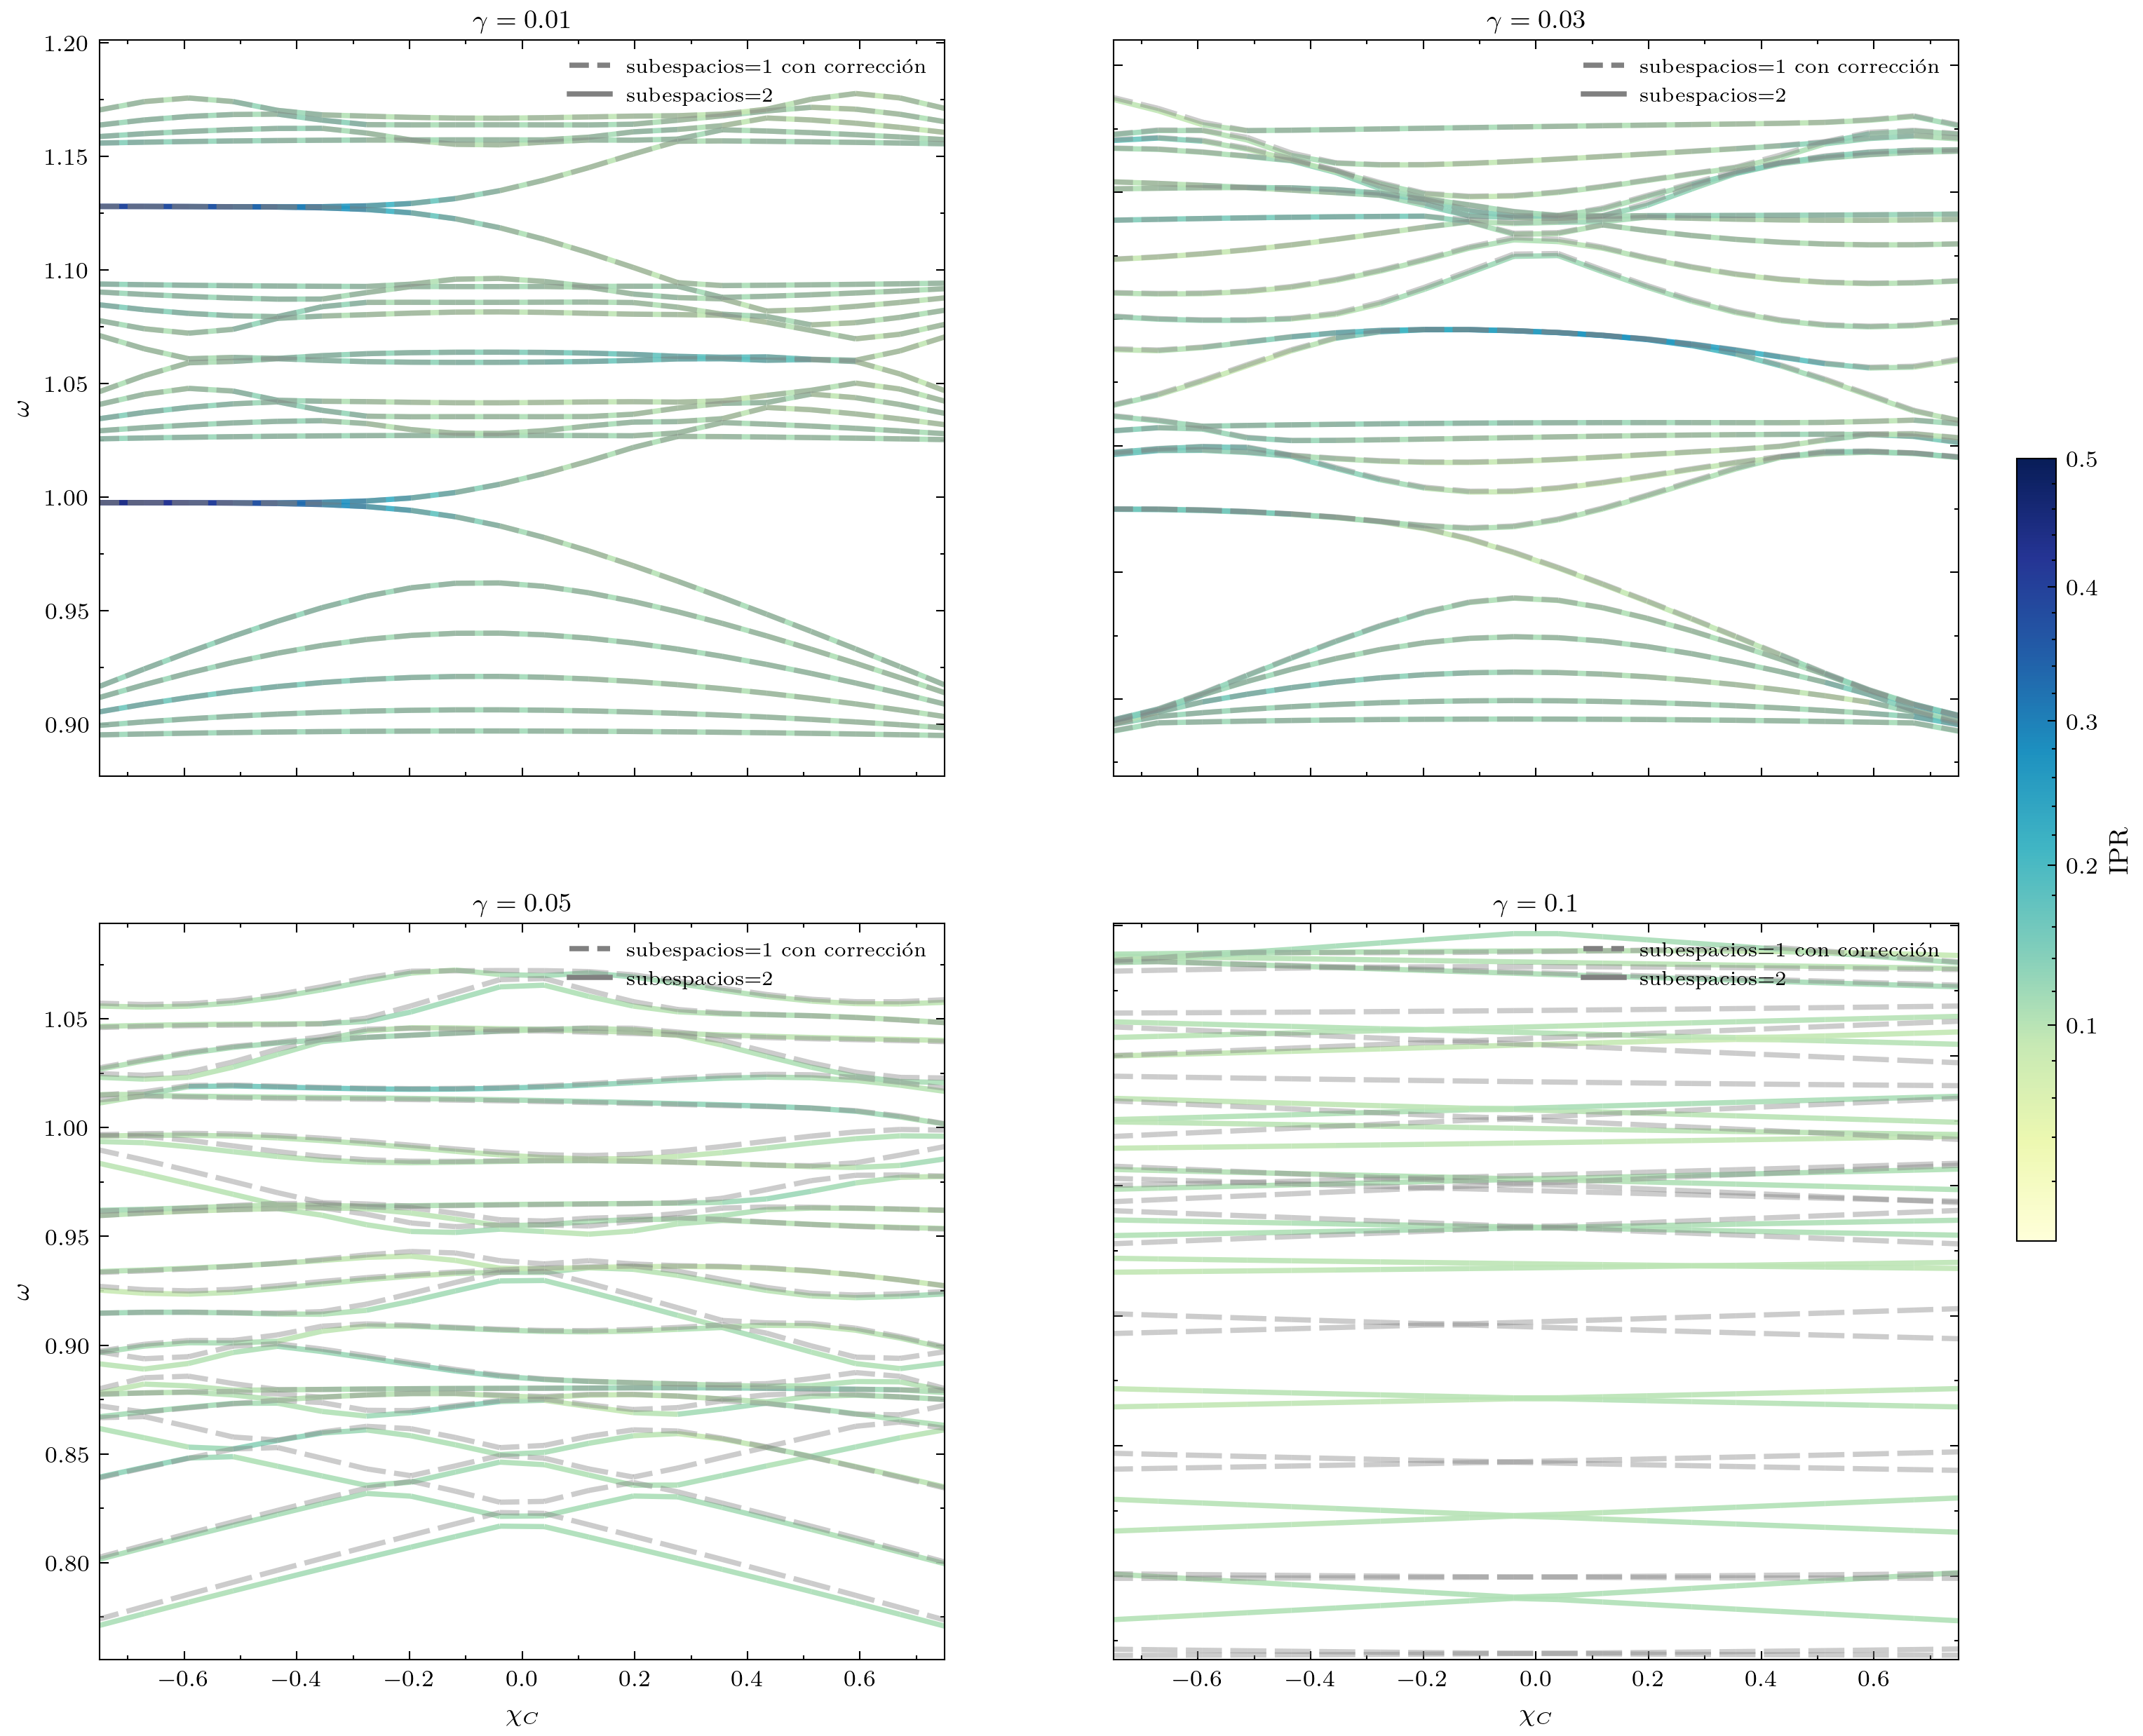

In [17]:
# ------------------------------------------------------------------ #
# Figure: 2x2, one panel per gamma
# ------------------------------------------------------------------ #
cmap     = plt.cm.YlGnBu
ipr_min  = 1e-4
ipr_max  = 0.5
norm_ipr = mcolors.PowerNorm(gamma=0.8, vmin=ipr_min, vmax=ipr_max)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, gamma in zip(axes.flatten(), gamma_values):
    energies1, iprs1, energies2, iprs2 = results[gamma]
    # model2: fock_layers=1 — IPR colored, solid
    for band_e, band_ipr in zip(energies2.T, iprs2.T):
        points   = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm_ipr,
                            linewidth=1.8, alpha=0.9, linestyle='-')
        lc.set_array(np.clip(0.5 * (band_ipr[:-1] + band_ipr[1:]), ipr_min, None))
        ax.add_collection(lc)
    # model1: SW correction — all gray, dashed
    for band_e in energies1.T:
        points   = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, colors='gray', linewidth=1.8, alpha=0.4, linestyle='--')
        ax.add_collection(lc)

    

    ax.plot([], [], color='gray', ls='--', lw=1.8, label='subespacios=1 con corrección')
    ax.plot([], [], color='gray', ls='-',  lw=1.8, label='subespacios=2')
    ax.legend(fontsize=7)

    ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
    e_all = np.concatenate([energies1.flatten(), energies2.flatten()])
    ax.set_ylim(e_all.min() - 0.02 * abs(e_all.min()),
                e_all.max() + 0.02 * abs(e_all.max()))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.set_title(rf'$\gamma = {gamma}$', fontsize=9, pad=4)

for ax in axes[1]:
    ax.set_xlabel(r'$\chi_C$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\omega$')
for ax in axes[0]:
    ax.tick_params(labelbottom=False)
for ax in axes[:, 1]:
    ax.tick_params(labelleft=False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_ipr)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.03)
cbar.set_label(r'IPR', fontsize=9)
plt.show()